# 04 — Feature engineering

Doel: van `aligned.parquet` naar een feature matrix + targets klaar voor modeling.

**Plan:**
1. Load aligned dataset (posts + AR/CAR targets).
2. Text preprocessing (lowercase, strip URLs, etc.) via `src.data.preprocess`.
3. **Chronologische** train/test split — nooit random op time series.
4. TF-IDF fit op **train only**, transform op test (geen leakage).
5. Targets voorbereiden:
   - Regression: continuous AR.
   - Classification: direction (up/down/neutral met dead-zone).
6. Save vectorizer + sparse matrices + targets als artifacts voor notebook 05.

**Critical anti-leakage rules:**
- Vectorizer fit ALLEEN op train.
- Geen normalization of feature selection met behulp van test data.
- Train/test split is chronologisch (geen `train_test_split(shuffle=True)`).


In [24]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from src.data.preprocess import clean_text

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
pandas=3.0.2, numpy=2.4.4


## 1. Load aligned dataset


In [25]:
aligned = pd.read_parquet("../data/processed/aligned.parquet")
aligned["timestamp_utc"] = pd.to_datetime(aligned["timestamp_utc"], utc=True)

print(f"Shape: {aligned.shape}")
print(f"Date range: {aligned['timestamp_utc'].min()} → {aligned['timestamp_utc'].max()}")
print(f"Targets aanwezig: {[c for c in aligned.columns if c.startswith(('ar_', 'car_'))]}")
aligned.head(3)

Shape: (26818, 14)
Date range: 2022-04-28 21:29:28.207000+00:00 → 2026-04-23 03:02:45.507000+00:00
Targets aanwezig: ['ar_1d_dxy', 'car_3d_dxy', 'ar_1d_spx', 'car_3d_spx', 'ar_1d_vix', 'car_3d_vix', 'ar_1d_wti', 'car_3d_wti']


,post_id,timestamp_utc,text,favorites,reposts,replies,ar_1d_dxy,car_3d_dxy,ar_1d_spx,car_3d_spx,ar_1d_vix,car_3d_vix,ar_1d_wti,car_3d_wti
0,108211822140637685,2022-04-28 21:29:28.207000+00:00,I’M BACK! #COVFEFE,410837,123196,60886,0.005206,0.002992,0.025065,-0.003509,-0.054215,0.008541,0.030339,0.024549
1,108217783188791701,2022-04-29 22:45:26.592000+00:00,Thank you to all of the GREAT and BEAUTIFUL Am...,217254,47614,19641,-0.008120,-0.006640,-0.036417,-0.021367,0.103781,-0.047792,-0.009816,-0.032533
2,108221053343991942,2022-04-30 12:37:05.206000+00:00,RT @catturd2Joe Biden is going to fly gas guzz...,0,0,0,0.005905,-0.008703,0.007843,0.046681,-0.041026,-0.299170,0.004025,0.031688


## 2. Tekstpreprocessing

We gebruiken `clean_text()` uit `src/data/preprocess.py`: lowercase, strip URLs/mentions,
keep hashtag-words. Filter posts < 5 tokens (te weinig signal).


In [26]:
aligned["text_clean"] = aligned["text"].apply(clean_text)
aligned["n_tokens"] = aligned["text_clean"].str.split().str.len()

n_before = len(aligned)
aligned = aligned[aligned["n_tokens"] >= 5].reset_index(drop=True)
print(f"Filtered {n_before:,} → {len(aligned):,} posts (dropped {n_before - len(aligned):,} short posts)")

# Quick check: voorbeeld vóór/na cleaning
sample = aligned.sample(3, random_state=1)
for _, row in sample.iterrows():
    print(f"\n--- {row['timestamp_utc']} ---")
    print(f"  raw:   {row['text'][:100]}")
    print(f"  clean: {row['text_clean'][:100]}")

Filtered 26,818 → 17,624 posts (dropped 9,194 short posts)

--- 2024-10-30 14:25:30.133000+00:00 ---
  raw:   Kelly Cooper is a fantastic America First Candidate running to represent the Great People of Arizona
  clean: kelly cooper is a fantastic america first candidate running to represent the great people of arizona

--- 2023-06-16 17:31:24.367000+00:00 ---
  raw:   Will Deranged Jack Smith be looking at the thousands of pages of documents that Biden had in Chinato
  clean: will deranged jack smith be looking at the thousands of pages of documents that biden had in chinato

--- 2022-12-17 12:17:27.743000+00:00 ---
  raw:   This (the FBI’s wild and crazy relationship with Twitter) is absolutely a coordinated effort to chan
  clean: this (the fbi’s wild and crazy relationship with twitter) is absolutely a coordinated effort to chan


## 3. Chronological train/test split

Eerste 80% in chronologische volgorde = train, laatste 20% = test.
Dit imiteert de echte deployment situatie: model leert van het verleden,
voorspelt de toekomst. **Geen** `random_state` shuffling.


In [27]:
TEST_SIZE = 0.20

aligned = aligned.sort_values("timestamp_utc").reset_index(drop=True)
n_train = int(len(aligned) * (1 - TEST_SIZE))

train = aligned.iloc[:n_train].copy()
test = aligned.iloc[n_train:].copy()

print(f"Train: {len(train):,} posts  | {train['timestamp_utc'].min().date()} → {train['timestamp_utc'].max().date()}")
print(f"Test:  {len(test):,} posts  | {test['timestamp_utc'].min().date()} → {test['timestamp_utc'].max().date()}")
split_date = train['timestamp_utc'].max()
print(f"\nCutoff date: {split_date.date()}")

Train: 14,099 posts  | 2022-04-29 → 2025-04-29
Test:  3,525 posts  | 2025-04-29 → 2026-04-23

Cutoff date: 2025-04-29


## 4. TF-IDF features

Fit op train tekst, transform op test. `min_df=5` filtert woorden die in <5
posts voorkomen (rare typos, eigennamen die slechts 1× gezegd zijn). `max_df=0.9`
filtert te-vaak-voorkomende woorden (bijna-stopwords).


In [28]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=5,
    max_df=0.9,
    sublinear_tf=True,      # 1 + log(tf), dampens dominant words
    stop_words="english",
)


X_train = vectorizer.fit_transform(train["text_clean"])
X_test = vectorizer.transform(test["text_clean"])

print(f"X_train: {X_train.shape}  (sparsity: {1 - X_train.nnz / np.prod(X_train.shape):.4f})")
print(f"X_test:  {X_test.shape}")
print(f"Vocab size: {len(vectorizer.vocabulary_):,}")
print(f"Voorbeeld features: {list(vectorizer.vocabulary_)[:10]}")

X_train: (14099, 5000)  (sparsity: 0.9956)
X_test:  (3525, 5000)
Vocab size: 5,000
Voorbeeld features: ['thank', 'great', 'beautiful', 'americans', 'return', 'social', 'media', 'proud', 'say', 'haters']


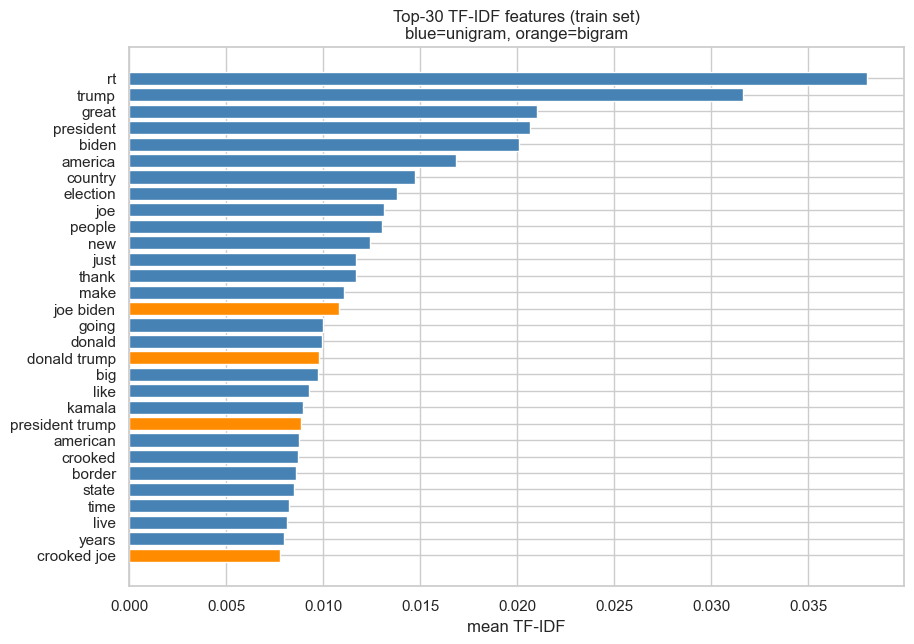

,feature,mean_tfidf,is_bigram
0,rt,0.038030,False
1,trump,0.031624,False
2,great,0.021029,False
3,president,0.020677,False
4,biden,0.020107,False
5,america,0.016849,False
6,country,0.014741,False
7,election,0.013778,False
8,joe,0.013104,False
9,people,0.013011,False


In [29]:
# Top features by mean TF-IDF in trainingset
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = X_train.mean(axis=0).A1
top_idx = np.argsort(mean_tfidf)[::-1][:30]

top_features_df = pd.DataFrame({
    "feature": feature_names[top_idx],
    "mean_tfidf": mean_tfidf[top_idx],
    "is_bigram": [(" " in f) for f in feature_names[top_idx]],
})

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["steelblue" if not b else "darkorange" for b in top_features_df["is_bigram"][::-1]]
ax.barh(top_features_df["feature"][::-1], top_features_df["mean_tfidf"][::-1], color=colors)
ax.set_title("Top-30 TF-IDF features (train set)\nblue=unigram, orange=bigram")
ax.set_xlabel("mean TF-IDF")
plt.show()
top_features_df.head(15)

## 5. Targets

We bouwen targets voor 4 (asset, window) combinaties: `{spx,wti} × {1d,3d}`.

**Regressie target**: continue abnormal return.

**Classification target**: 3-class direction met dead-zone:
- `up` als AR > +threshold
- `down` als AR < −threshold
- `neutral` anders

Threshold = 0.001 (10 bps) per `config.yaml`. Aanpasbaar per asset (WTI is ~2.3× volatieler dan SPX).


In [30]:
TARGET_COLS = ["ar_1d_spx", "car_3d_spx", "ar_1d_wti", "car_3d_wti"]

# Per-target dead zone: 0.2 × training set std
DEAD_ZONES = {col: 0.2 * train[col].std() for col in TARGET_COLS}
print("Dead zones (per target):")
for col, dz in DEAD_ZONES.items():
    print(f"  {col}: ±{dz*1e4:.1f} bp  (={dz:.5f})")


def encode_direction(y: pd.Series, threshold: float) -> pd.Series:
    return pd.Series(
        np.where(y > threshold, "up",
                 np.where(y < -threshold, "down", "neutral")),
        index=y.index, name=f"{y.name}_dir",
    )


y_train_reg = {}
y_test_reg = {}
y_train_cls = {}
y_test_cls = {}

for col in TARGET_COLS:
    threshold = DEAD_ZONES[col]
    y_train_reg[col] = train[col]
    y_test_reg[col] = test[col]
    y_train_cls[col] = encode_direction(train[col], threshold)
    y_test_cls[col] = encode_direction(test[col], threshold)



# Class distributions
print("--- Class distribution per target (train set) ---")
for col in TARGET_COLS:
    counts = y_train_cls[col].value_counts()
    pct = (counts / counts.sum() * 100).round(1)
    print(f"  {col}: {dict(zip(counts.index, [f'{c} ({p}%)' for c, p in zip(counts, pct)]))}")

Dead zones (per target):
  ar_1d_spx: ±21.0 bp  (=0.00210)
  car_3d_spx: ±35.7 bp  (=0.00357)
  ar_1d_wti: ±44.2 bp  (=0.00442)
  car_3d_wti: ±77.0 bp  (=0.00770)
--- Class distribution per target (train set) ---
  ar_1d_spx: {'down': '5650 (40.1%)', 'up': '4884 (34.6%)', 'neutral': '3565 (25.3%)'}
  car_3d_spx: {'up': '5828 (41.3%)', 'down': '5590 (39.6%)', 'neutral': '2681 (19.0%)'}
  ar_1d_wti: {'up': '6156 (43.7%)', 'down': '5882 (41.7%)', 'neutral': '2061 (14.6%)'}
  car_3d_wti: {'up': '6089 (43.2%)', 'down': '5816 (41.3%)', 'neutral': '2194 (15.6%)'}


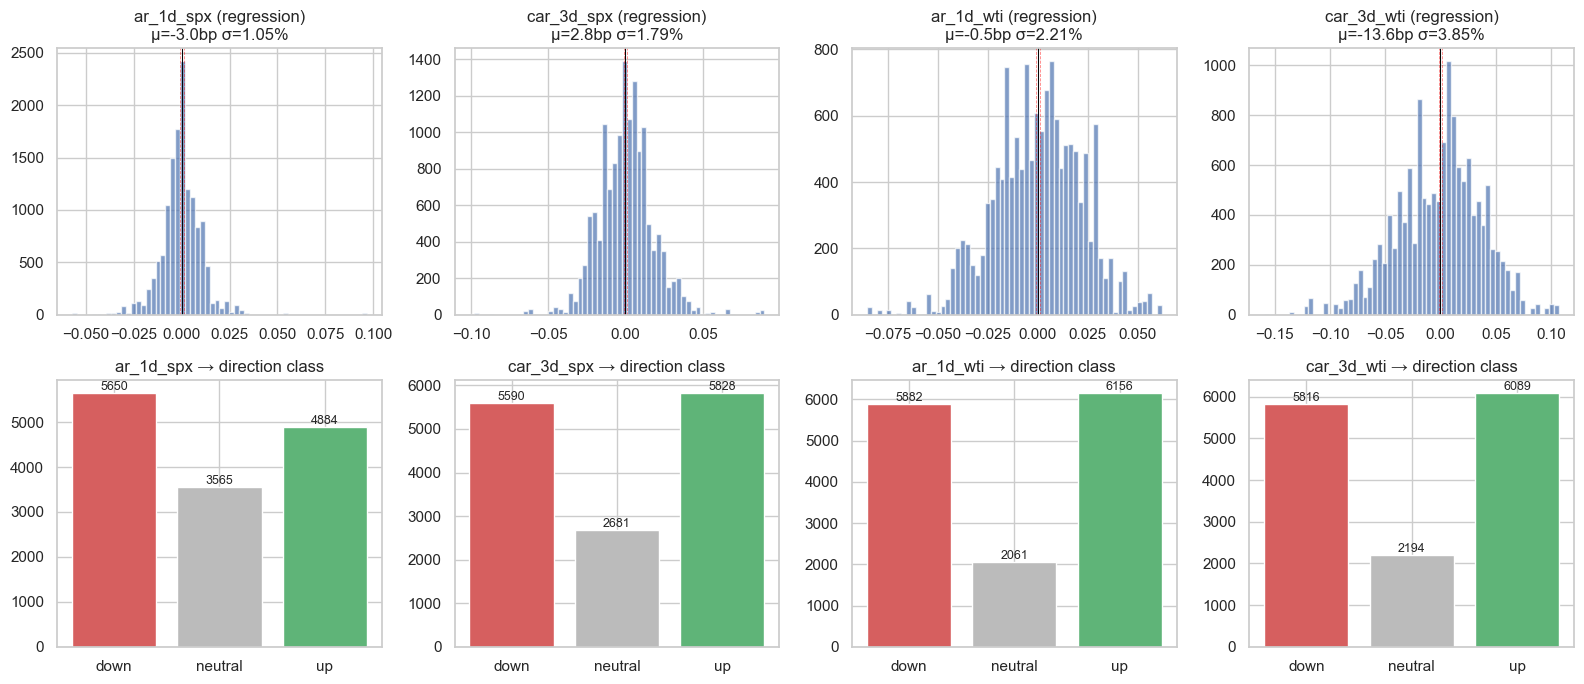

In [31]:
# Visualiseer target distributies
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, col in enumerate(TARGET_COLS):
    # Top row: regression
    ax = axes[0, j]
    train_vals = train[col].dropna()
    ax.hist(train_vals, bins=60, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.7)
    ax.axvline(DEAD_ZONE, color="red", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.axvline(-DEAD_ZONE, color="red", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_title(f"{col} (regression)\nμ={train_vals.mean()*1e4:.1f}bp σ={train_vals.std()*100:.2f}%")

    # Bottom row: classification
    ax = axes[1, j]
    counts = y_train_cls[col].value_counts().reindex(["down", "neutral", "up"], fill_value=0)
    colors = ["#d65f5f", "#bbbbbb", "#5fb478"]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white")
    ax.set_title(f"{col} → direction class")
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()

## 6. Optionele extra features (engagement)

Voeg favorites/reposts/replies toe als auxiliary features, ge-log-transformed.
Random Forest kan deze direct combineren met TF-IDF.


In [32]:
from scipy.sparse import csr_matrix, hstack

def build_aux_features(df: pd.DataFrame) -> csr_matrix:
    """Engagement features: log1p van counts."""
    aux = np.log1p(df[["favorites", "reposts", "replies"]].fillna(0).values)
    return csr_matrix(aux)


X_train_aux = build_aux_features(train)
X_test_aux = build_aux_features(test)

X_train_full = hstack([X_train, X_train_aux]).tocsr()
X_test_full = hstack([X_test, X_test_aux]).tocsr()

# Feature names: vocab + aux columns
all_feature_names = list(feature_names) + ["log_favorites", "log_reposts", "log_replies"]
print(f"Combined feature matrix: {X_train_full.shape}  (last 3 = engagement)")

Combined feature matrix: (14099, 5003)  (last 3 = engagement)


## 7. Save artifacts voor notebook 05

We slaan op:
- `vectorizer.joblib` — voor toekomstige inferentie op nieuwe posts.
- `features.joblib` — dict met X_train_full, X_test_full, feature_names.
- `targets.joblib` — dict met y_train_reg, y_test_reg, y_train_cls, y_test_cls.
- `metadata.joblib` — split_date, dead_zone, train/test sizes.


In [33]:
artifacts_dir = Path("../data/processed/features")
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, artifacts_dir / "vectorizer.joblib")
joblib.dump({
    "X_train": X_train_full,
    "X_test": X_test_full,
    "feature_names": all_feature_names,
    "train_post_ids": train["post_id"].tolist(),
    "test_post_ids": test["post_id"].tolist(),
}, artifacts_dir / "features.joblib")
joblib.dump({
    "regression": {"train": y_train_reg, "test": y_test_reg},
    "classification": {"train": y_train_cls, "test": y_test_cls},
}, artifacts_dir / "targets.joblib")
joblib.dump({
    "split_date": split_date.isoformat(),
    "dead_zone": DEAD_ZONE,
    "n_train": len(train),
    "n_test": len(test),
    "n_features": X_train_full.shape[1],
    "target_cols": TARGET_COLS,
}, artifacts_dir / "metadata.joblib")

print(f"Wrote artifacts to {artifacts_dir.resolve()}:")
for p in sorted(artifacts_dir.iterdir()):
    print(f"  {p.name:25s}  {p.stat().st_size:>10,} bytes")

Wrote artifacts to /Users/quintenfriederichs/code/truthsocial-marketimpact/data/processed/features:
  features.joblib             6,022,279 bytes
  metadata.joblib                   194 bytes
  targets.joblib              1,961,593 bytes
  vectorizer.joblib             193,388 bytes


## 8. Bevindingen & next steps

**Wat we nu hebben:**
- TF-IDF feature matrix met ~5k woorden + bigrams (op train) + 3 engagement features.
- 4 regression targets (continuous AR) en 4 classification targets (3-class direction).
- Chronologische split met clean cutoff date.
- Alles weggeschreven als joblib artifacts.

**Class balance**: voor de synthetic data ziet de up/down/neutral verdeling er
redelijk gebalanceerd uit. In echte data, met de meeste posts geen meetbaar
effect, zal *neutral* domineren — overweeg `class_weight="balanced"` in RF.

**Volgende stap (notebook 05):**
- Baselines: dummy, L1-logistic, Ridge.
- Random Forest classifier en regressor.
- Hyperparameter tuning met TimeSeriesSplit + Optuna.
- Per asset (spx, wti) × per window (1d, 3d) = 4 model-paren.

**Open vragen:**
- Per-asset threshold (in plaats van flat 0.001) i.f.v. asset-vol?
- Stopwords-filter erbij voor TF-IDF, of houden we 'em vanwege Trump's stijl
  ("I", "the", etc. zijn deel van zijn voice)?
